In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# from nltk.tokenize import word_tokenize
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.model_selection import train_test_split
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.model_selection import cross_val_score
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import roc_curve, auc
# from sklearn.metrics import roc_auc_score
# from sklearn.metrics import precision_recall_curve
# from sklearn.metrics import average_precision_score
# from sklearn.metrics import f1_score
# from sklearn.metrics import precision_score
# from sklearn.metrics import recall_score
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import classification_report
# from sklearn.metrics import plot_confusion_matrix
# from sklearn.metrics import plot_roc_curve
# from sklearn.metrics import plot_precision_recall_curve
# from sklearn.metrics import plot_roc_curve
# from sklearn.metrics import plot_precision_recall_curve
# from sklearn.metrics import plot_roc_curve

In [7]:
# import MBTI types and Birthdays (Responses).csv as a dataframe from the 
# Kaggle MBTI dataset
df = pd.read_csv(r"C:\Users\TOSHIBA\Documents\Github\FateAi\DATAS\MBTI types and Birthdays (Responses).csv")

In [8]:
df.sample(10)

,Timestamp,Birthday,Time of Birth (not required),MBTI Type
91,4/13/2020 0:48:48,12/3/2000,NaN,INTP
141,4/13/2020 4:01:22,1/26/2000,NaN,ESFP
238,4/13/2020 10:59:12,2/23/1994,7:10:00 AM,INFP
239,4/13/2020 11:05:37,2/26/2003,9:35:00 PM,INFP
86,4/13/2020 0:41:20,1/6/2000,1:50:00 PM,INTP
92,4/13/2020 0:52:54,12/28/2000,12:05:00 PM,INFP
240,4/13/2020 11:16:43,8/12/1993,NaN,ENTJ
84,4/13/2020 0:36:18,2/23/2000,5:10:00 AM,ENFP
143,4/13/2020 4:06:51,12/26/2000,2:58:00 AM,ENTP
55,4/12/2020 23:22:42,8/11/2000,NaN,INTP


In [11]:
from datetime import datetime, timedelta

def convert_time_12h_to_24h(time_str):
    """
    將12小時制時間字符串轉換為24小時制時間對象

    參數:
    time_str (str): 一個形如"1:25:00 AM"的12小時制時間字符串

    返回:
    datetime.time: 轉換後的24小時制時間對象
    """
    dt = datetime.strptime(time_str, "%I:%M:%S %p")
    return dt.time()


In [12]:
# apply the function to the non NaN "Time of Birth (not required)" column, and make a new column named "TOB_24h"
df["TOB_24h"] = df["Time of Birth (not required)"].apply(lambda x: convert_time_12h_to_24h(x) if not pd.isnull(x) else x)



In [13]:
df

,Timestamp,Birthday,Time of Birth (not required),MBTI Type,TOB_24h
0,4/12/2020 17:39:37,9/13/1996,NaN,INFJ,NaN
1,4/12/2020 17:45:59,3/8/2000,NaN,ISTJ,NaN
2,4/12/2020 17:58:56,8/20/2000,NaN,INTP,NaN
3,4/12/2020 18:10:25,6/30/2000,NaN,INFP,NaN
4,4/12/2020 18:10:27,6/30/2000,NaN,INFP,NaN
...,...,...,...,...,...
301,4/16/2020 3:45:22,2/21/1993,1:25:00 AM,INFP,01:25:00
302,4/16/2020 3:45:30,2/21/1993,1:25:00 AM,INFP,01:25:00
303,4/16/2020 17:02:07,1/1/2007,4:00:00 AM,ENTP,04:00:00
304,4/16/2020 17:05:03,1/1/2001,3:00:00 AM,ENTP,03:00:00


In [14]:
# drop the "Time of Birth (not required)" column
df.drop("Time of Birth (not required)", axis=1, inplace=True)

In [15]:
# get only the hour and create new column "TOB_hour"
df["TOB_hour"] = df["TOB_24h"].apply(lambda x: x.hour if not pd.isnull(x) else x)

In [16]:
#conver the non NaN "TOB_hour" column to int
df["TOB_hour"] = df["TOB_hour"].apply(lambda x: int(x) if not pd.isnull(x) else x)

In [17]:
# get only the month and create new column "DOB_month" from the col Birthday (mm/dd/yyyy)
df["DOB_month"] = df["Birthday"].apply(lambda x: int(x.split("/")[0]) if not pd.isnull(x) else x)


In [18]:
# get only the day and create new column "DOB_day" from the col Birthday (mm/dd/yyyy)
df["DOB_day"] = df["Birthday"].apply(lambda x: int(x.split("/")[1]) if not pd.isnull(x) else x)
# get only the year and create new column "DOB_year" from the col Birthday (mm/dd/yyyy)
df["DOB_year"] = df["Birthday"].apply(lambda x: int(x.split("/")[2]) if not pd.isnull(x) else x)


In [19]:
df

,Timestamp,Birthday,MBTI Type,TOB_24h,TOB_hour,DOB_month,DOB_day,DOB_year
0,4/12/2020 17:39:37,9/13/1996,INFJ,NaN,NaN,9,13,1996
1,4/12/2020 17:45:59,3/8/2000,ISTJ,NaN,NaN,3,8,2000
2,4/12/2020 17:58:56,8/20/2000,INTP,NaN,NaN,8,20,2000
3,4/12/2020 18:10:25,6/30/2000,INFP,NaN,NaN,6,30,2000
4,4/12/2020 18:10:27,6/30/2000,INFP,NaN,NaN,6,30,2000
...,...,...,...,...,...,...,...,...
301,4/16/2020 3:45:22,2/21/1993,INFP,01:25:00,1.0,2,21,1993
302,4/16/2020 3:45:30,2/21/1993,INFP,01:25:00,1.0,2,21,1993
303,4/16/2020 17:02:07,1/1/2007,ENTP,04:00:00,4.0,1,1,2007
304,4/16/2020 17:05:03,1/1/2001,ENTP,03:00:00,3.0,1,1,2001


In [20]:
# count the number of non NaN values in TOB_hour
df["TOB_hour"].count()

159

In [49]:
# get only rows with non NaN values in TOB_hour and make a new dataframe named withHours
# withHours = df[df["TOB_hour"].notnull()]
withHours =df

In [50]:
import functions as f


In [56]:
# create a new col 八字 and apply the function f.getBazi to the "DOB_year", "DOB_month", "DOB_day", "TOB_hour" columns
withHours["八字"] = withHours.apply(lambda x: f.getBazi(x["DOB_year"], x["DOB_month"], x["DOB_day"], 1), axis=1)


changed sth
输入:[1996-9-13]; 输出:[1996-8-1]; 天干地支:[丙子-丁酉-癸丑]; 生肖:[鼠]
changed sth
输入:[2000-3-8]; 输出:[2000-2-3]; 天干地支:[庚辰-己卯-乙丑]; 生肖:[龍]
changed sth
输入:[2000-8-20]; 输出:[2000-7-21]; 天干地支:[庚辰-甲申-庚戌]; 生肖:[龍]
changed sth
输入:[2000-6-30]; 输出:[2000-5-29]; 天干地支:[庚辰-壬午-己未]; 生肖:[龍]
changed sth
输入:[2000-6-30]; 输出:[2000-5-29]; 天干地支:[庚辰-壬午-己未]; 生肖:[龍]
changed sth
输入:[2000-9-12]; 输出:[2000-8-15]; 天干地支:[庚辰-乙酉-癸酉]; 生肖:[龍]
changed sth
输入:[2000-2-4]; 输出:[2000-12-29]; 天干地支:[庚辰-戊寅-壬辰]; 生肖:[龍]
changed sth
输入:[2000-8-1]; 输出:[2000-7-2]; 天干地支:[庚辰-癸未-辛卯]; 生肖:[龍]
changed sth
输入:[2000-3-24]; 输出:[2000-2-19]; 天干地支:[庚辰-己卯-辛巳]; 生肖:[龍]
changed sth
输入:[2000-4-9]; 输出:[2000-3-5]; 天干地支:[庚辰-庚辰-丁酉]; 生肖:[龍]
changed sth
输入:[2000-7-12]; 输出:[2000-6-11]; 天干地支:[庚辰-癸未-辛未]; 生肖:[龍]
changed sth
输入:[2000-12-15]; 输出:[2000-11-20]; 天干地支:[庚辰-戊子-丁未]; 生肖:[龍]
changed sth
输入:[2000-6-4]; 输出:[2000-5-3]; 天干地支:[庚辰-辛巳-癸巳]; 生肖:[龍]
changed sth
输入:[2000-3-17]; 输出:[2000-2-12]; 天干地支:[庚辰-己卯-甲戌]; 生肖:[龍]
changed sth
输入:[2000-10-13]; 输出:[2000-9-16]; 天干地支:[庚辰-丙

In [57]:
f.getBazi(1996, 9,17, 3)

changed sth
输入:[1996-9-17]; 输出:[1996-8-5]; 天干地支:[丙子-丁酉-丁巳]; 生肖:[鼠]


['丙', '子', '丁', '酉', '丁', '巳', '壬', '寅']

In [58]:
withHours

,Timestamp,Birthday,MBTI Type,TOB_24h,TOB_hour,DOB_month,DOB_day,DOB_year,八字
0,4/12/2020 17:39:37,9/13/1996,INFJ,NaN,NaN,9,13,1996,"[丙, 子, 丁, 酉, 癸, 丑, 癸, 丑]"
1,4/12/2020 17:45:59,3/8/2000,ISTJ,NaN,NaN,3,8,2000,"[庚, 辰, 己, 卯, 乙, 丑, 丁, 丑]"
2,4/12/2020 17:58:56,8/20/2000,INTP,NaN,NaN,8,20,2000,"[庚, 辰, 甲, 申, 庚, 戌, 丁, 丑]"
3,4/12/2020 18:10:25,6/30/2000,INFP,NaN,NaN,6,30,2000,"[庚, 辰, 壬, 午, 己, 未, 乙, 丑]"
4,4/12/2020 18:10:27,6/30/2000,INFP,NaN,NaN,6,30,2000,"[庚, 辰, 壬, 午, 己, 未, 乙, 丑]"
...,...,...,...,...,...,...,...,...,...
301,4/16/2020 3:45:22,2/21/1993,INFP,01:25:00,1.0,2,21,1993,"[癸, 酉, 甲, 寅, 癸, 酉, 癸, 丑]"
302,4/16/2020 3:45:30,2/21/1993,INFP,01:25:00,1.0,2,21,1993,"[癸, 酉, 甲, 寅, 癸, 酉, 癸, 丑]"
303,4/16/2020 17:02:07,1/1/2007,ENTP,04:00:00,4.0,1,1,2007,"[丙, 戌, 庚, 子, 乙, 未, 丁, 丑]"
304,4/16/2020 17:05:03,1/1/2001,ENTP,03:00:00,3.0,1,1,2001,"[庚, 辰, 戊, 子, 甲, 子, 乙, 丑]"


In [59]:
# create a new col "rizhu" and get the fifth character of the "八字" column
withHours["rizhu"] = withHours["八字"].apply(lambda x: x[4])

In [68]:
# create a new col "yueling" and get the forth character of the "八字" column
withHours["yueling"] = withHours["八字"].apply(lambda x: x[3])

In [69]:
withHours.sample(3)

,Timestamp,Birthday,MBTI Type,TOB_24h,TOB_hour,DOB_month,DOB_day,DOB_year,八字,rizhu,rizhu_yinyang,rizhu_wuxing,rizhu_en,yueling
198,4/13/2020 8:18:18,5/8/2000,INTJ,19:05:00,19.0,5,8,2000,"[庚, 辰, 辛, 巳, 丙, 寅, 己, 丑]",丙,陽,火,bing,巳
106,4/13/2020 1:30:11,10/31/2000,INFP,21:36:00,21.0,10,31,2000,"[庚, 辰, 丙, 戌, 壬, 戌, 辛, 丑]",壬,陽,水,ren,戌
39,4/12/2020 22:38:52,5/30/2000,INFP,NaN,NaN,5,30,2000,"[庚, 辰, 辛, 巳, 戊, 子, 癸, 丑]",戊,陽,土,wu,巳


In [61]:
# get the ying and yang of the rizhu using yin_yang_dict
yin_yang_dict = {"甲": "陽", "乙": "陰", "丙": "陽", "丁": "陰", "戊": "陽", "己": "陰", "庚": "陽", "辛": "陰", "壬": "陽", "癸": "陰"}
withHours["rizhu_yinyang"] = withHours["rizhu"].apply(lambda x: yin_yang_dict[x])

In [62]:
# get the wuxing of the rizhu using wuxing_dict
wuxing_dict = {"甲": "木", "乙": "木", "丙": "火", "丁": "火", "戊": "土", "己": "土", "庚": "金", "辛": "金", "壬": "水", "癸": "水"}
withHours["rizhu_wuxing"] = withHours["rizhu"].apply(lambda x: wuxing_dict[x])


In [63]:
withHours


,Timestamp,Birthday,MBTI Type,TOB_24h,TOB_hour,DOB_month,DOB_day,DOB_year,八字,rizhu,rizhu_yinyang,rizhu_wuxing
0,4/12/2020 17:39:37,9/13/1996,INFJ,NaN,NaN,9,13,1996,"[丙, 子, 丁, 酉, 癸, 丑, 癸, 丑]",癸,陰,水
1,4/12/2020 17:45:59,3/8/2000,ISTJ,NaN,NaN,3,8,2000,"[庚, 辰, 己, 卯, 乙, 丑, 丁, 丑]",乙,陰,木
2,4/12/2020 17:58:56,8/20/2000,INTP,NaN,NaN,8,20,2000,"[庚, 辰, 甲, 申, 庚, 戌, 丁, 丑]",庚,陽,金
3,4/12/2020 18:10:25,6/30/2000,INFP,NaN,NaN,6,30,2000,"[庚, 辰, 壬, 午, 己, 未, 乙, 丑]",己,陰,土
4,4/12/2020 18:10:27,6/30/2000,INFP,NaN,NaN,6,30,2000,"[庚, 辰, 壬, 午, 己, 未, 乙, 丑]",己,陰,土
...,...,...,...,...,...,...,...,...,...,...,...,...
301,4/16/2020 3:45:22,2/21/1993,INFP,01:25:00,1.0,2,21,1993,"[癸, 酉, 甲, 寅, 癸, 酉, 癸, 丑]",癸,陰,水
302,4/16/2020 3:45:30,2/21/1993,INFP,01:25:00,1.0,2,21,1993,"[癸, 酉, 甲, 寅, 癸, 酉, 癸, 丑]",癸,陰,水
303,4/16/2020 17:02:07,1/1/2007,ENTP,04:00:00,4.0,1,1,2007,"[丙, 戌, 庚, 子, 乙, 未, 丁, 丑]",乙,陰,木
304,4/16/2020 17:05:03,1/1/2001,ENTP,03:00:00,3.0,1,1,2001,"[庚, 辰, 戊, 子, 甲, 子, 乙, 丑]",甲,陽,木


In [64]:
# conver rizhu to english
rizhu_dict = {"甲": "jia", "乙": "yi", "丙": "bing", "丁": "ding", "戊": "wu", "己": "ji", "庚": "geng", "辛": "xin", "壬": "ren", "癸": "gui"}
withHours["rizhu_en"] = withHours["rizhu"].apply(lambda x: rizhu_dict[x])


In [70]:
# conver yueling to english
yueling_dict = {"子": "zi", "丑": "chou", "寅": "yin", "卯": "mao", "辰": "chen", "巳": "si", "午": "wu", "未": "wei", "申": "shen", "酉": "you", "戌": "xu", "亥": "hai"}
withHours["yueling_en"] = withHours["yueling"].apply(lambda x: yueling_dict[x])


P: 0.7065713435292127
The variables are not correlated with each other.


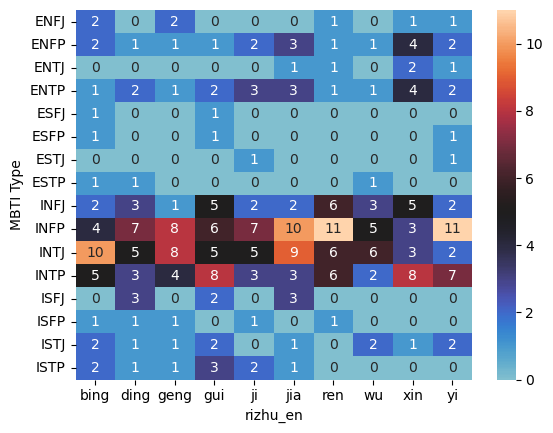

In [65]:
crrlt_count=pd.crosstab(withHours["MBTI Type"],withHours["rizhu_en"])
sns.heatmap(crrlt_count,center=5,annot=True, fmt="d")
from scipy import stats  
ChiSqResult = stats.chi2_contingency(crrlt_count, correction=False)
p_value = ChiSqResult[1]
print(f"P: {p_value}")
if p_value>=0.05:
    print("The variables are not correlated with each other.")
else:
    print("The variables are correlated with each other.")

<AxesSubplot:>

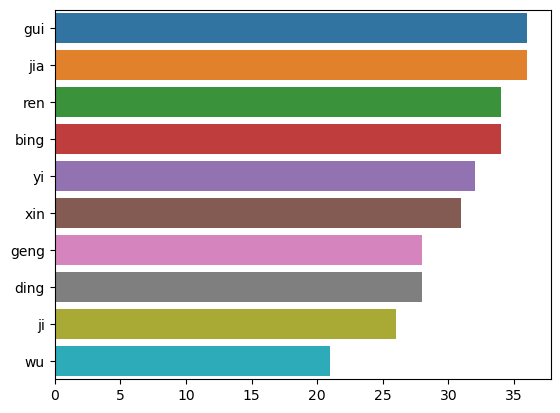

In [66]:
rizhu_count = df['rizhu_en'].value_counts()
sns.barplot(y=rizhu_count.index,x=rizhu_count.values)

<AxesSubplot:>

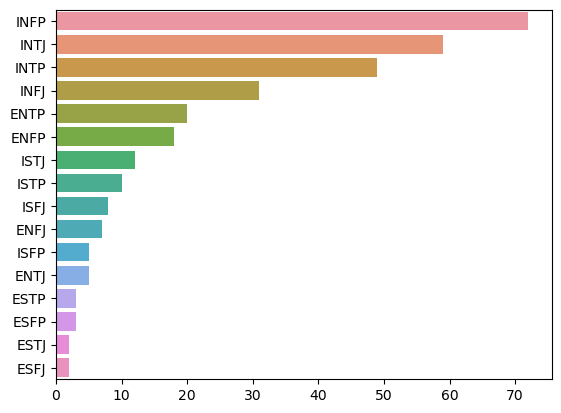

In [67]:
mbti_counts = df['MBTI Type'].value_counts()
sns.barplot(y=mbti_counts.index,x=mbti_counts.values)

In [71]:
def get_liunian_dayun_tiangan_dizhi(bazi, year):
    tiangan = ['甲', '乙', '丙', '丁', '戊', '己', '庚', '辛', '壬', '癸']
    dizhi = ['子', '丑', '寅', '卯', '辰', '巳', '午', '未', '申', '酉', '戌', '亥']

    # Convert bazi string to a list of four integers
    bazi_list = [int(x) for x in bazi]

    # Calculate the number of years elapsed since the birth year
    elapsed_years = year - bazi_list[0]

    # Calculate the index of the current liunian cycle
    liunian_index = elapsed_years % 60

    # Calculate the index of the current dayun cycle
    dayun_index = elapsed_years % 10

    # Calculate the tiangan and dizhi for the current liunian cycle
    liunian_tiangan_index = (liunian_index % 10 + 6) % 10
    liunian_dizhi_index = (liunian_index % 12 + 2) % 12
    liunian_tiangan = tiangan[liunian_tiangan_index]
    liunian_dizhi = dizhi[liunian_dizhi_index]
    liunian = f"{liunian_tiangan}{liunian_dizhi}"

    # Calculate the tiangan and dizhi for the current dayun cycle
    dayun_tiangan_index = (dayun_index + bazi_list[3] // 2) % 10
    dayun_dizhi_index = (bazi_list[3] + dayun_index) % 12
    dayun_tiangan = tiangan[dayun_tiangan_index]
    dayun_dizhi = dizhi[dayun_dizhi_index]
    dayun = f"{dayun_tiangan}{dayun_dizhi}"

    # Return the corresponding liunian and dayun cycles with their tiangan dizhi
    return liunian, dayun


In [72]:
get_liunian_dayun_tiangan_dizhi("19960917", 2023)

('壬申', '己申')

In [73]:
def get_ganzi(year):
    tiangan = ['甲', '乙', '丙', '丁', '戊', '己', '庚', '辛', '壬', '癸']
    dizhi = ['子', '丑', '寅', '卯', '辰', '巳', '午', '未', '申', '酉', '戌', '亥']

    tiangan_index = (year - 4) % 10
    dizhi_index = (year - 4) % 12

    return f"{tiangan[tiangan_index]}{dizhi[dizhi_index]}"


In [76]:
def get_dayun(bazi):
    tiangan = ['甲', '乙', '丙', '丁', '戊', '己', '庚', '辛', '壬', '癸']
    dizhi = ['子', '丑', '寅', '卯', '辰', '巳', '午', '未', '申', '酉', '戌', '亥']

    # Convert bazi string to a list of four integers
    bazi_list = [int(x) for x in bazi]

    # Calculate the tiangan index for the current dayun cycle
    dayun_tiangan_index = (bazi_list[3] // 2) % 10

    # Calculate the dizhi index for the current dayun cycle
    dayun_dizhi_index = (bazi_list[3] + 8) % 12

    # Initialize a list to store the dayun periods
    dayun_periods = []

    # Loop through 10 dayun periods
    for i in range(10):
        # Calculate the tiangan and dizhi for the current dayun period
        tiangan_index = (dayun_tiangan_index + i) % 10
        dizhi_index = (dayun_dizhi_index + i) % 12
        tiangan_str = tiangan[tiangan_index]
        dizhi_str = dizhi[dizhi_index]

        # Add the current dayun period to the list
        dayun_periods.append(f"{tiangan_str}{dizhi_str}")

    return dayun_periods


In [81]:
get_dayun("19960917")

'-5岁4个月0天'

In [80]:
from datetime import datetime

def get_dayun(birthday):
    # Convert birthday string to datetime object
    bdate = datetime.strptime(birthday, '%Y%m%d')
    year, month, day = bdate.year, bdate.month, bdate.day
    
    # Find the next and previous solar terms from the birthday
    sterm_next = datetime.strptime(f'{year}-{month}-01', '%Y-%m-%d')
    sterm_prev = datetime.strptime(f'{year}-{month}-01', '%Y-%m-%d')
    for i in range(24):
        sterm_next = sterm_next.replace(month=(month+i-1)%12+1)
        sterm_prev = sterm_prev.replace(month=(month-i+11)%12+1)
        if sterm_next.month == 2 and sterm_next.day >= 4:
            break
        if sterm_prev.month == 2 and sterm_prev.day >= 4:
            break
    
    # Calculate the number of days and hours between the birthday and the next/previous solar term
    if bdate < sterm_next:
        days = (sterm_next - bdate).days
        hours = (sterm_next - bdate).seconds // 3600
        sex = 'F' if bdate.year % 2 == 0 else 'M'
    else:
        days = (bdate - sterm_prev).days
        hours = (bdate - sterm_prev).seconds // 3600
        sex = 'M' if bdate.year % 2 == 0 else 'F'
    
    # Convert days and hours to years, months, and days
    years = days // 3
    months = (days % 3) * 4
    months += hours // 180
    days = hours % 180 // 24
    if sex == 'F':
        years += 1
    
    # Return the dayun as a string
    return f'{years}岁{months}个月{days}天'

